<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center><font size=10>Artificial Intelligence and Machine Learning</center></font></h1>



<center> <font size=6> Project Python Foundations: FoodHub Data Analysis

<center><img src="https://www.netsolutions.com/wp-content/uploads/2022/10/essential-features-of-building-an-on-demand-food-ordering-app.jpg" width="720"></center>


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [2]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [3]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [4]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Write your code here to read the data
df = pd.read_csv('/content/drive/MyDrive/Python/FoodHub/foodhub_order.csv')

In [5]:
# Write your code here to view the first 5 rows
df.head(5)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [28]:
# Write your code here
df.shape

(1898, 9)

### Observations: The data has 1898 row and 9 columns


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [29]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations: The attributes are of different data types (int, float, object) in the data

*   4 columns order_id, customer_id, food_preparation_time and delivery _time are of data type int64.
*   4 columns restaurant_name, cuisine_type, day_of_the_week and rating are of object data type.
*   1 column cost_of_the_order is of float64 data type.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [30]:
# checking missing values across each columns
df.isnull().sum()
#df.notna().sum()


,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations: No, the are none missing values in the data


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [31]:
# Statistical summary of the data
print(df.describe())

# Minimum, average, and maximum time it takes for food to be prepared once an order is placed
#df['food_preparation_time'].describe()

print('Minimum Preparation Time:',df['food_preparation_time'].min(), 'minutes')
print('Average Preparation Time:',round(df['food_preparation_time'].mean(),2), 'minutes')
print('Maximum  Preparation Time:',df['food_preparation_time'].max(), 'minutes')

           order_id    customer_id  cost_of_the_order  food_preparation_time  \
count  1.898000e+03    1898.000000        1898.000000            1898.000000   
mean   1.477496e+06  171168.478398          16.498851              27.371970   
std    5.480497e+02  113698.139743           7.483812               4.632481   
min    1.476547e+06    1311.000000           4.470000              20.000000   
25%    1.477021e+06   77787.750000          12.080000              23.000000   
50%    1.477496e+06  128600.000000          14.140000              27.000000   
75%    1.477970e+06  270525.000000          22.297500              31.000000   
max    1.478444e+06  405334.000000          35.410000              35.000000   

       delivery_time  
count    1898.000000  
mean       24.161749  
std         4.972637  
min        15.000000  
25%        20.000000  
50%        25.000000  
75%        28.000000  
max        33.000000  
Minimum Preparation Time: 20 minutes
Average Preparation Time: 27.37 min

#### Observations: The minimum food preparation time is 20 minutes
 The average is 27.37 minute

 The maximum is 35 minutes


### **Question 5:** How many orders are not rated? [1 mark]

In [32]:
# Write the code here
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


#### Observations: 736 orders are not rated.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

**6.1. order_id**

In [33]:
# Write the code here
# Check order_id
df['order_id'].nunique()


1898

**6.2. customer_id**

In [34]:
# check unique order ID
df['customer_id'].nunique()

1200

**6.3. resturant_name**

In [35]:
# check unique Restaurant Name
df['restaurant_name'].nunique()

178

**6.4. cusine_type**

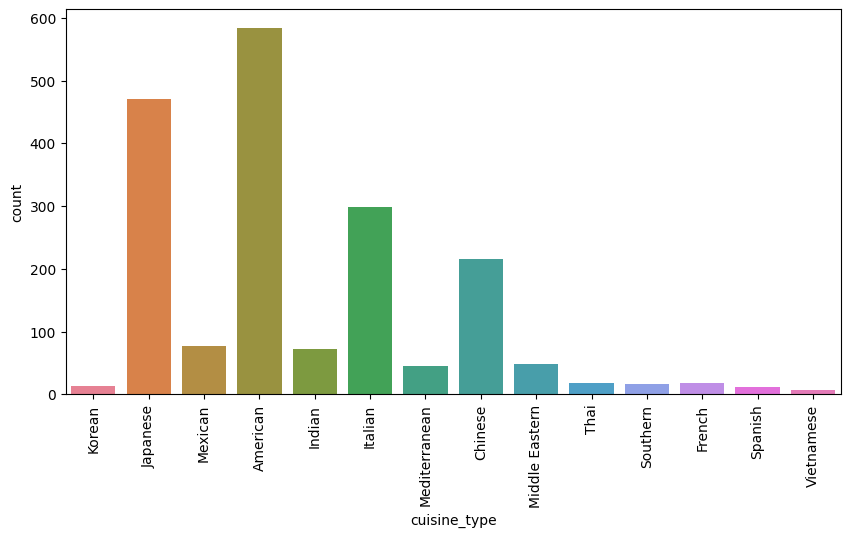

In [36]:
# Check unique cuisine type
df['cuisine_type'].unique()

# Code for a countplot for cuisine type.
plt.figure(figsize = (10,5))
sns.countplot(data = df, x = 'cuisine_type',hue='cuisine_type')
plt.xticks(rotation=90)
plt.show()

Observation: The most popular cuisine types is American followed by Japanese, Italian and Chinese

**6.5. cost_of_the_order**

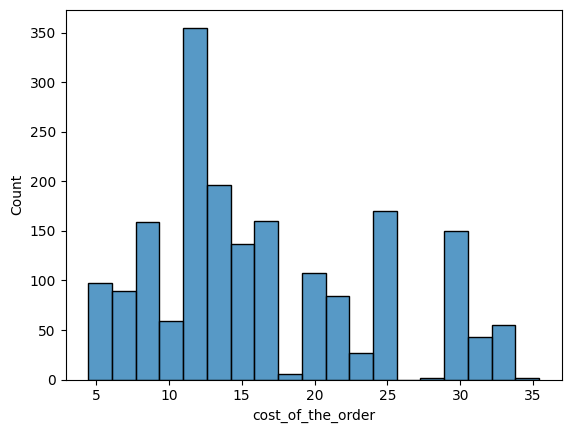

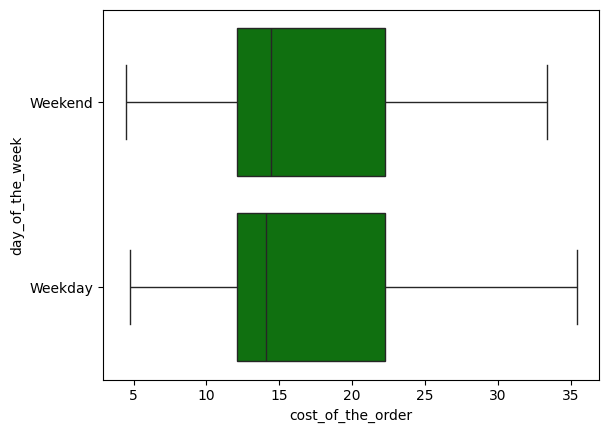

In [37]:
# Histogram for the cost of order
sns.histplot(data=df,x='cost_of_the_order')
plt.show()
# Boxplot for the cost of order
sns.boxplot(data=df,x='cost_of_the_order', y='day_of_the_week', color='green')
plt.show()

Observation: Distribution of costs indicate right skewness, with a maximum order count of around 12 dollars

**6.6. day_of_the_week**

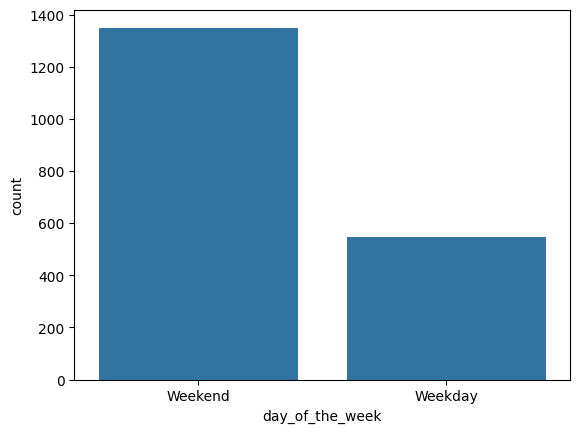

In [38]:
#Check the unique values
df['day_of_the_week'].nunique()

#Code to plot a bar graph for 'day_of_the_week' column
sns.countplot(data = df, x = 'day_of_the_week')
plt.show()


Observation: There are more orders on weekends than on weekdays

**6.8. food_preparation_time**

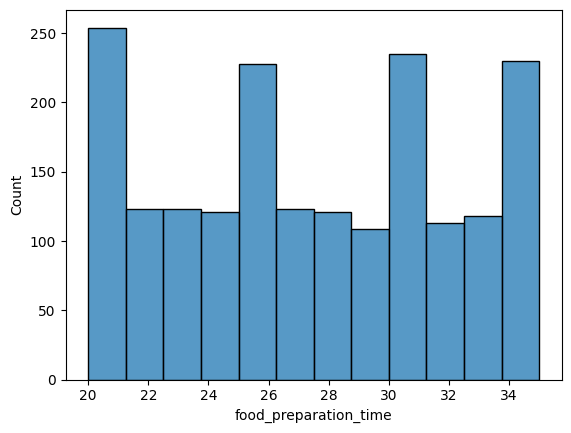

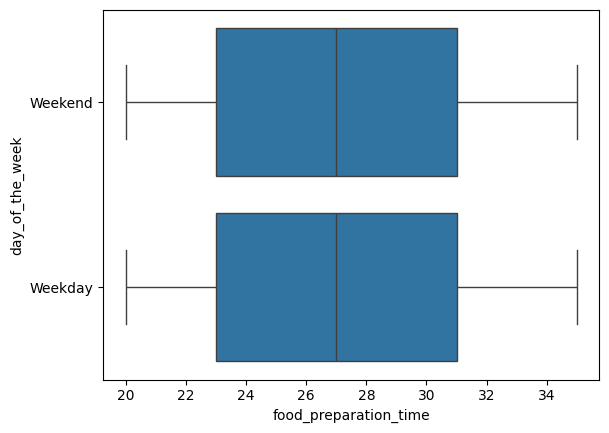

In [39]:
# Code to plot the histogram for the 'food_preparation_time' column
sns.histplot(data=df,x='food_preparation_time')
plt.show()
# Code to plot the boxplot for the 'food_preparation_time' column
sns.boxplot(data=df,x='food_preparation_time',y='day_of_the_week')
plt.show()

Observation: The food preparation time are similar across weekdays and weekends, with a relatively balanced distribution around the median, at 27 minutes.

**6.9. delivery_time**

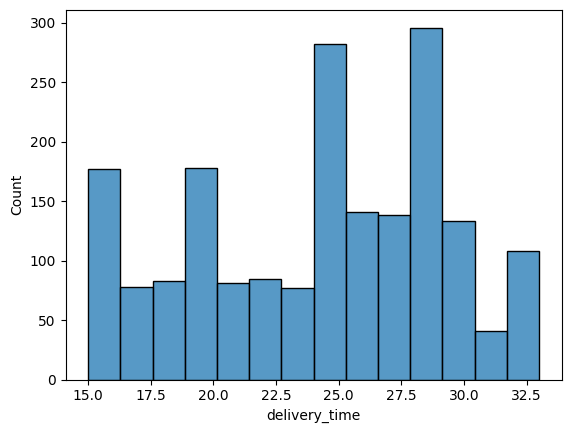

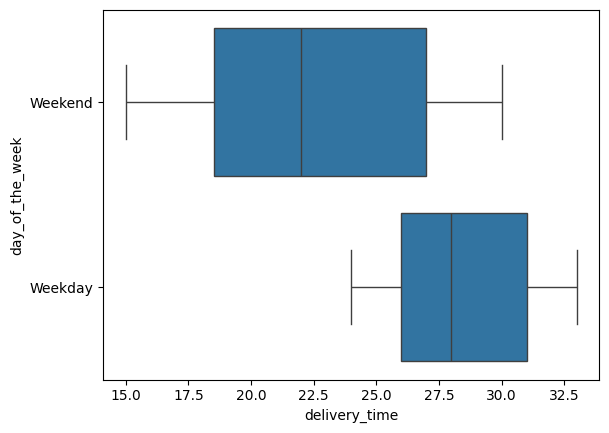

In [40]:
# Code to plot the histogram for the 'delivery_time' column
sns.histplot(data=df,x='delivery_time')
plt.show()
# Code to plot the boxplot for the 'delivery_time' column
sns.boxplot(data=df,x='delivery_time',y='day_of_the_week')
plt.show()

Observation: The delivery times are longer during weekdays than on weekends

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [41]:
# Code for top 5 restaurants in terms of orders received
df['restaurant_name'].value_counts().head(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations: The top five restaurants are Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken and Parm, from the most orders to the least


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [42]:
# Code for most popular cuisine on weekends

weekend_data = df[df['day_of_the_week']=='Weekend']

most_popular_cuisine = weekend_data['cuisine_type'].value_counts().idxmax()
most_popular_cuisine_count= weekend_data['cuisine_type'].value_counts().max()
print('The most popular cuisine on weekends is: ',most_popular_cuisine,'with count',most_popular_cuisine_count)

The most popular cuisine on weekends is:  American with count 415


#### Observations: The most popular cuisine on weekends is American with count of total oders of 415 on weekends


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [43]:
# Orders that cost above 20 dollars
orders_greater_than_20=df[df['cost_of_the_order']>20]


# Total number of orders that cost above 20 dollars : no of rows
orders_greater_than_20.shape[0]

# Percentage of orders that cost above 20 dollars
percentage_orders=(orders_greater_than_20.shape[0]/df.shape[0])*100

print('Percentage of orders that cost more than 20 dollars = ',round(percentage_orders,2), '%')

Percentage of orders that cost more than 20 dollars =  29.24 %


#### Observations: 29.24% of all orders cost more than 20 dollars. A significant majority of orders currently cost less than 20 dollars.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [44]:
# Mean of oder delivery time
mean_delivery_time=df['delivery_time'].mean()

print('Mean of oder delivery time is', round(mean_delivery_time,2),'minutes')

Mean of oder delivery time is 24.16 minutes


#### Observations: The mean order delivery time is 24.16 minutes.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [45]:
# Code to get top 3 most frequent customers
print("Top 3 most frequent customers and their number of orders:")
df['customer_id'].value_counts().head(3)

Top 3 most frequent customers and their number of orders:


,count
customer_id,
52832,13
47440,10
83287,9


#### Observations: Customers with ids 52832, 47440 and 83287 have placed 13, 10 and 9 orders respectively, which makes them the top three most frequent customers.


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


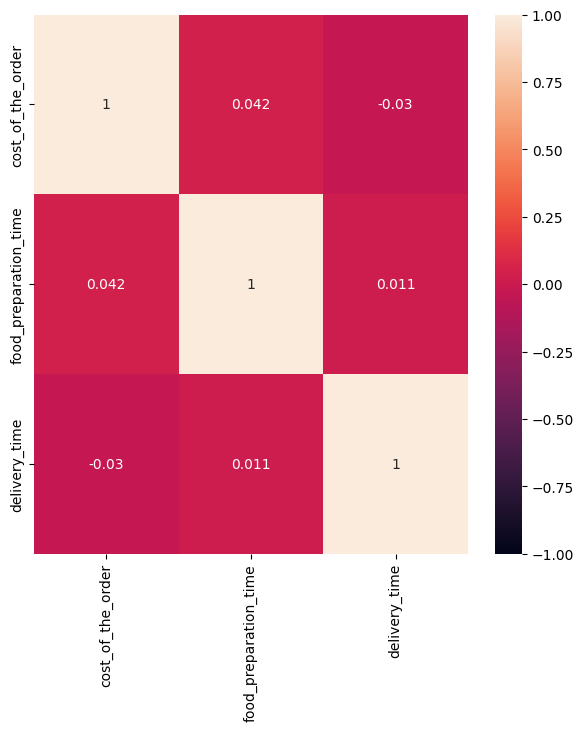

In [46]:
# Write the code here
col_list = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
plt.figure(figsize=(7, 7))
sns.heatmap(df[col_list].corr(), annot=True, vmin=-1, vmax=1)
plt.xticks(rotation=90)
plt.show()

Observations: The correlation matrix, is a heatmap, shows weak correlation between variables overall.

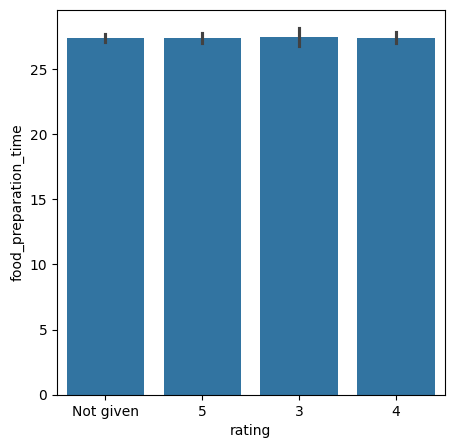

In [13]:
# food_preparation_time vs rating
plt.figure(figsize=(5, 5))
sns.barplot(data=df, x='rating',y='food_preparation_time')
plt.show()

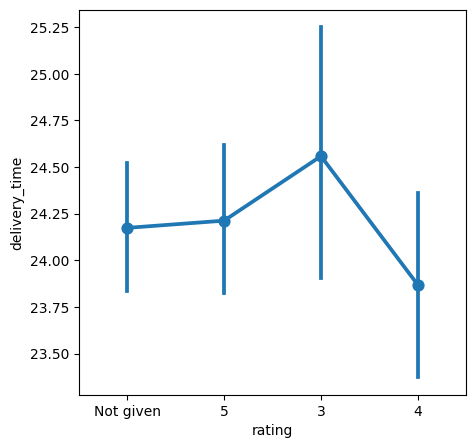

In [15]:
# delivery_time vs rating
plt.figure(figsize=(5, 5))
sns.pointplot(data=df, x='rating',y='delivery_time')
plt.show()

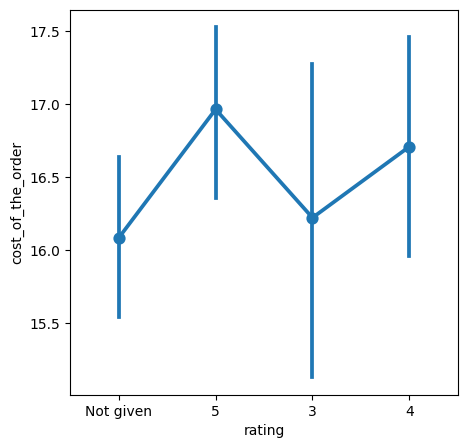

In [17]:
# cost_of_the_order vs rating
plt.figure(figsize=(5, 5))
sns.pointplot(data=df, x='rating',y='cost_of_the_order')
plt.show()

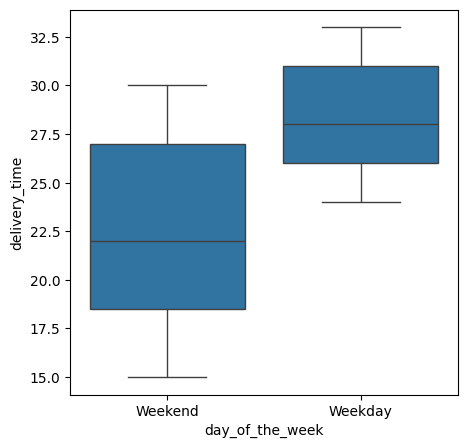

In [19]:
# delivery_time vs days_of_the_week
plt.figure(figsize=(5, 5))
sns.boxplot(data=df, x='day_of_the_week',y='delivery_time')
plt.show()

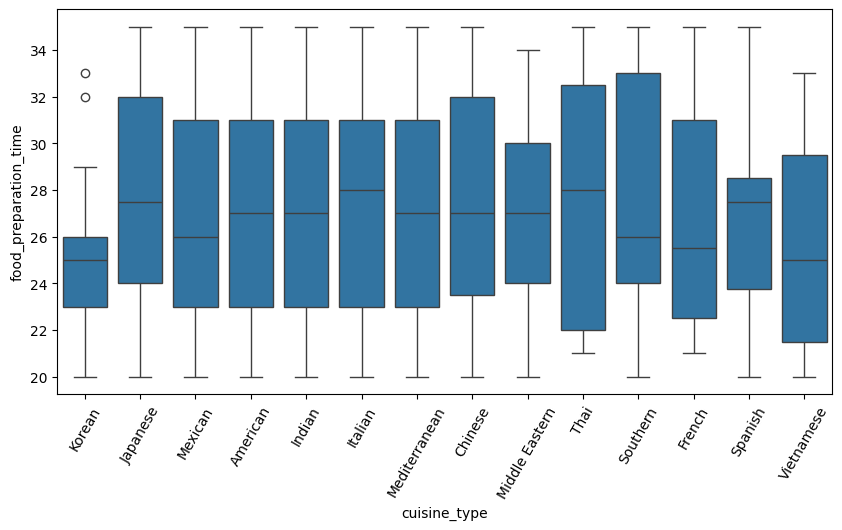

In [26]:
# food_preparation_time vs cuisine_type
plt.figure(figsize=(10, 5))
sns. boxplot(data=df, x='cuisine_type',y='food_preparation_time')
plt.xticks(rotation = 60)
plt.show()

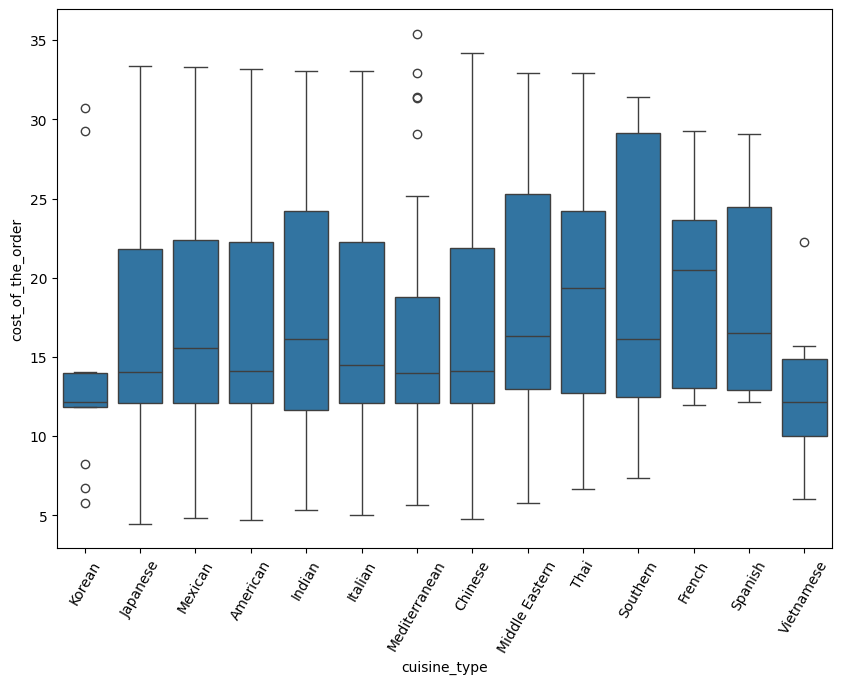

In [27]:
# cost_of_the_order vs cuisine_type
plt.figure(figsize=(10, 7))
sns. boxplot(data=df, x='cuisine_type',y='cost_of_the_order')
plt.xticks(rotation = 60)
plt.show()

Observations: Most frequently ordered cuisine types present consistent spreads among them,

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [47]:
# Filter 'rating' column
df_new_rating = df[df['rating'] != 'Not given'].copy()

# Code to convert data type of 'rating' column from object to integer
df_new_rating['rating']=df_new_rating['rating'].astype('int')
df_new_rating['rating'].info()

# Group by restaurant name and aggregate the count and mean of ratings
df_new_rest = df_new_rating.groupby('restaurant_name')['rating'].agg(['count', 'mean'])

#filter for rating count more than 50 and average rating greater than 4
restaurants_qualifying = df_new_rest[(df_new_rest['count'] > 50)& (df_new_rest['mean']>4)]

print(restaurants_qualifying)





<class 'pandas.core.series.Series'>
Index: 1162 entries, 2 to 1896
Series name: rating
Non-Null Count  Dtype
--------------  -----
1162 non-null   int64
dtypes: int64(1)
memory usage: 18.2 KB
                           count      mean
restaurant_name                           
Blue Ribbon Fried Chicken     64  4.328125
Blue Ribbon Sushi             73  4.219178
Shake Shack                  133  4.278195
The Meatball Shop             84  4.511905


#### Observations: Restaurants Shake Shack, The Meatball Shop, Blue Ribbo Sushi and Blue Ribbon Fried Chicken all qualify for the promotion.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [48]:
# Function to calculate the revenue
def compute_revenue(x):
    if x > 20:
        return x*0.25
    elif x > 5:
        return x*0.15
    else:
        return x*0

df['revenue'] = df['cost_of_the_order'].apply(compute_revenue)

# Calculate the net revenue
net_revenue = df['revenue'].sum()

print('Net revenue generated by the company across all orders is',round(net_revenue,2),'dollars')


Net revenue generated by the company across all orders is 6166.3 dollars


#### Observations: The net revenue is $6166.303 across all orders.


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [49]:
# Calculate total time required to deliver the food
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

# Calculate the percentage of orders that have more than 60 minutes of total delivery time
percentage_orders = (df['total_time'] > 60).mean() * 100

'''# or
orders_greater_than_60= df[df['total_time'] > 60]

# Percentage of orders that cost above 20 dollars
percentage_orders=(orders_greater_than_60.shape[0]/df.shape[0])*100'''

print('Percentage of orders that take more than 60 minutes to get delivered from the time the order is placed is',round(percentage_orders,2),'%')

Percentage of orders that take more than 60 minutes to get delivered from the time the order is placed is 10.54 %


#### Observations: Around 10.54% of all orders take more than 60 minutes to get delivered from the time the order is placed.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [50]:
# Mean delivery time on weekdays
mean_delivery_time_weekdays = df[df['day_of_the_week']=='Weekday']['delivery_time'].mean()

print('Mean delivery time on weekdays is',round(mean_delivery_time_weekdays,2),'minutes')

# Mean delivery time on weekends
mean_delivery_time_weekends = df[df['day_of_the_week']=='Weekend']['delivery_time'].mean()

print('Mean delivery time on weekends is',round(mean_delivery_time_weekends,2),'minutes')

Mean delivery time on weekdays is 28.34 minutes
Mean delivery time on weekends is 22.47 minutes


#### Observations:Mean delivery time on weekdays is 28.34 minutes and the
Mean delivery time on weekends is 22.47 minutes.

Mean time of delivery is markedly shorter on weekends, however the number of orders which is significantly higher during weekends.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  Weekend days experience significantly higher orders compared to weekdays.
*  The most popular cuisine types is American followed by Japanese, Italian and Chinese.
*  A significant majority of orders cost less than 20 dollars.
*  Around 10% of orders exceed a total delivery time of 60 minutes, risking customer dissatisfaction.

### Recommendations:

*  Gathering additional ratings should be focused on.
*  Some improvement can be made in reducing the delivery time during weekends to handle surge demand.
*  Introduce promotions on high-value orders and top-rated restaurants (e.g., Shake Shack) to increase revenue.


---